In [1]:
import os
import numpy as np
import geopandas as gpd
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW 
import matplotlib.pyplot as plt
from rasterstats import zonal_stats

In [2]:
os.chdir('..')
os.getcwd()

'/Users/rujalshrestha/Projects/mac-migration/gisc-412/nepal-wildfire'

In [3]:
bardiya_topo = gpd.read_file('output/Topography/bardiya_topography.gpkg')
bardiya_topo.head()

,NAME_4,mean_elev,mean_slope,mean_aspect,FIRE_COUNT,geometry
0,Badalpur,149.550405,89.918392,192.298721,2.0,"MULTIPOLYGON (((81.12878 28.44646, 81.13213 28..."
1,Baganaha,172.409699,89.321476,191.434135,23.0,"MULTIPOLYGON (((81.35322 28.41987, 81.34365 28..."
2,Baniyabhar,173.485520,89.554248,187.456953,162.0,"MULTIPOLYGON (((81.30164 28.36481, 81.30537 28..."
3,Belawa,369.133084,89.920006,185.877821,83.0,"MULTIPOLYGON (((81.59071 28.23619, 81.59232 28..."
4,Bhimapur,143.615370,89.862659,190.219705,11.0,"MULTIPOLYGON (((81.15041 28.37132, 81.13278 28..."


In [4]:
ndvi_stats = zonal_stats(bardiya_topo, "data/Climate/Bardiya_NDVI.tif", stats=["mean"])
lst_stats = zonal_stats(bardiya_topo, "data/Climate/Bardiya_LST.tif", stats=["mean"])
temp_stats = zonal_stats(bardiya_topo, "data/Climate/Bardiya_Temp.tif", stats=["mean"])
precip_stats = zonal_stats(bardiya_topo, "data/Climate/Bardiya_Precip.tif", stats=["mean"])

bardiya_topo["mean_ndvi"] = [x["mean"] for x in ndvi_stats]
bardiya_topo["mean_lst"] = [x["mean"] for x in lst_stats]
bardiya_topo["mean_temp"] = [x["mean"] for x in temp_stats]
bardiya_topo["mean_precip"] = [x["mean"] for x in precip_stats]

# scaling and adjusting the variables
bardiya_topo["mean_ndvi"] = bardiya_topo["mean_ndvi"] / 10000  # scaling to 0 - 1 scale
bardiya_topo["mean_lst"] = bardiya_topo["mean_lst"] - 273.15   # LST Kelvin → °C
bardiya_topo["mean_temp"] = (bardiya_topo["mean_temp"] / 10)   # scaled by 10 on original data

bardiya_topo = bardiya_topo.fillna(bardiya_topo.mean(numeric_only=True))

bardiya_topo.to_file("output/gwr/bardiya_gwr_data.gpkg", driver="GPKG")

print(bardiya_topo.head())
print(bardiya_topo.columns)

       NAME_4   mean_elev  mean_slope  mean_aspect  FIRE_COUNT  \
0    Badalpur  149.550405   89.918392   192.298721         2.0   
1    Baganaha  172.409699   89.321476   191.434135        23.0   
2  Baniyabhar  173.485520   89.554248   187.456953       162.0   
3      Belawa  369.133084   89.920006   185.877821        83.0   
4    Bhimapur  143.615370   89.862659   190.219705        11.0   

                                            geometry  mean_ndvi   mean_lst  \
0  MULTIPOLYGON (((81.12878 28.44646, 81.13213 28...   0.542839  28.730773   
1  MULTIPOLYGON (((81.35322 28.41987, 81.34365 28...   0.580512  28.016801   
2  MULTIPOLYGON (((81.30164 28.36481, 81.30537 28...   0.614688  27.927044   
3  MULTIPOLYGON (((81.59071 28.23619, 81.59232 28...   0.603104  27.227609   
4  MULTIPOLYGON (((81.15041 28.37132, 81.13278 28...   0.534063  28.132983   

   mean_temp  mean_precip  
0  24.600000  1640.611111  
1  24.409434  1667.094340  
2  24.352439  1634.487805  
3  23.395690  1581.448

/Users/rujalshrestha/Projects/mac-migration/gisc-412/gisc-env/lib/python3.13/site-packages/rasterstats/io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


# preprocessing

In [5]:
gwr_data = bardiya_topo.copy()

gwr_data = gwr_data.dropna(subset=["FIRE_COUNT", "mean_elev", "mean_slope", "mean_aspect",
                                   "mean_ndvi", "mean_lst", "mean_temp", "mean_precip"])

# Dependent variable (Fire count), reshaping into 2D vector as expected by GWR
y = gwr_data["FIRE_COUNT"].values.reshape((-1, 1))

# Independent variables
X = gwr_data[["mean_elev", "mean_slope", "mean_aspect", "mean_ndvi",
              "mean_lst", "mean_temp", "mean_precip"]].values

# Coordinates (centroids of municipalities)
coords = np.array([(geom.centroid.x, geom.centroid.y) for geom in gwr_data.geometry])

bw = Sel_BW(coords, y, X, fixed=False).search(bw_min=2)

# Fit GWR model

In [6]:
gwr_model = GWR(coords, y, X, bw, fixed=False, kernel='bisquare')
gwr_results = gwr_model.fit()

print(gwr_results.summary())

gwr_data["local_R2"] = gwr_results.localR2
gwr_data.to_file("output/gwr/Bardiya_GWR_Results.gpkg", driver="GPKG")


Model type                                                         Gaussian
Number of observations:                                                  33
Number of covariates:                                                     8

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                        4282116.953
Log-likelihood:                                                    -241.087
AIC:                                                                498.174
AICc:                                                               508.000
BIC:                                                            4282029.541
R2:                                                                   0.672
Adj. R2:                                                              0.580

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

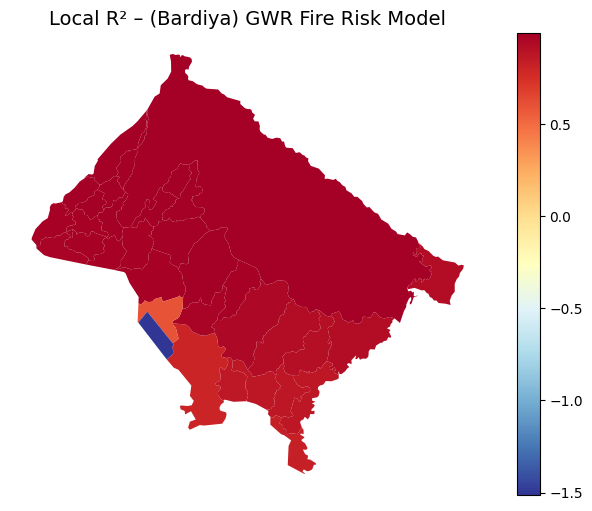

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
gwr_data.plot(column="local_R2", cmap="RdYlBu_r", legend=True, ax=ax)
ax.set_title("Local R² – (Bardiya) GWR Fire Risk Model", fontsize=14)
plt.axis("off")
plt.show()